X shape: (1000, 20, 1)
y shape: (1000,)
Train samples: 800
Test samples: 200


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0403 - val_loss: 0.0118
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0072 - val_loss: 0.0033
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 9.0787e-04
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.1326e-04 - val_loss: 6.7363e-04
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.5049e-04 - val_loss: 5.6740e-04
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.5539e-04 - val_loss: 5.1204e-04
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.8592e-04 - val_loss: 4.7078e-04
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3011e-04 - val_loss: 4.2261e-04
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8366e-04 - val_loss: 3.5437e-04
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3993e-04 - val_loss: 2.7067e-04
Epoch 12/20


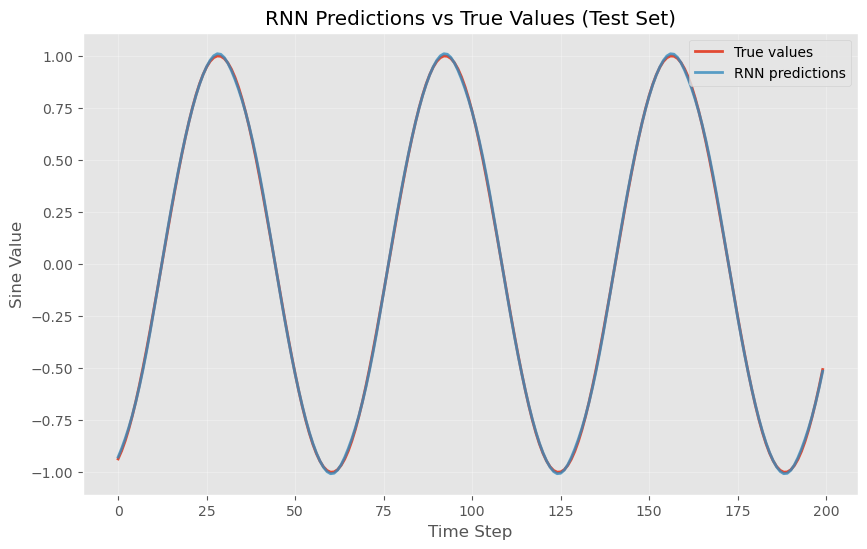

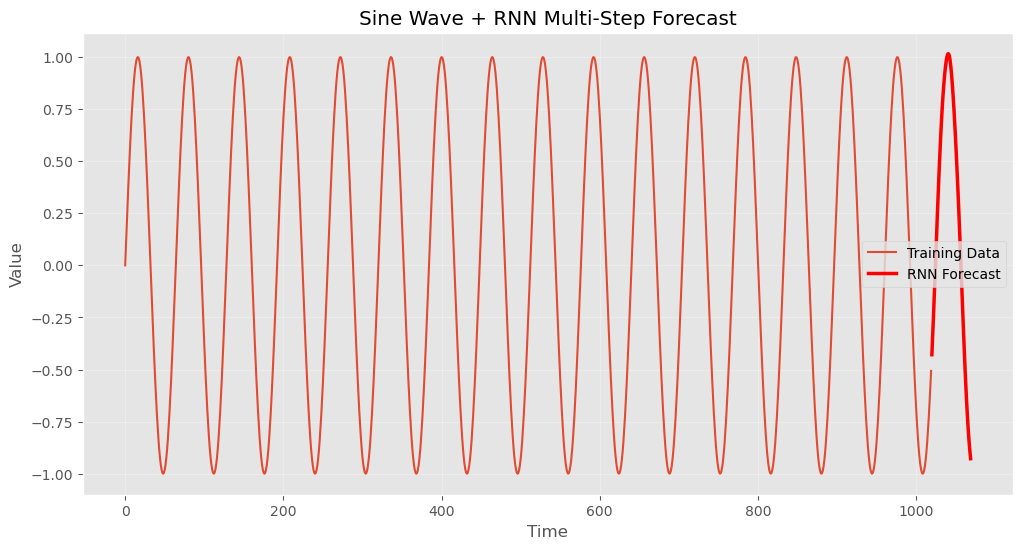

✅ RNN example complete!
Final test loss: 0.000037


In [18]:
# ============================================
# Recurrent Neural Network (RNN) Example
# Simple sequence prediction on sine wave data
# Jupyter Notebook ready - copy each cell below
# ============================================

# =============================================================================
# Cell 1: Imports
# =============================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Cell 2: Generate toy data (sine wave sequences)
# =============================================================================
seq_len = 20
total_seqs = 1000
t = np.linspace(0, 100, total_seqs + seq_len)
data = np.sin(t)

X = []
y = []
for i in range(total_seqs):
    X.append(data[i:i+seq_len])
    y.append(data[i+seq_len])

X = np.array(X)
y = np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))  # (samples, timesteps, features)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# =============================================================================
# Cell 3: Train-test split
# =============================================================================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# =============================================================================
# Cell 4: Model definition
# =============================================================================
model = Sequential([
    SimpleRNN(units=32, activation='tanh', input_shape=(seq_len, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# =============================================================================
# Cell 5: Train the model
# =============================================================================
history = model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)

# =============================================================================
# Cell 6: Evaluate and visualize predictions
# =============================================================================
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.6f}")

# Plot predictions vs true values
y_pred = model.predict(X_test, verbose=0)

plt.figure(figsize=(10, 6))
plt.plot(y_test[:200], label='True values', linewidth=2)
plt.plot(y_pred[:200], label='RNN predictions', linewidth=2, alpha=0.8)
plt.title('RNN Predictions vs True Values (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Sine Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =============================================================================
# Cell 7: Multi-step forecasting (Bonus)
# =============================================================================
def forecast(model, seed_seq, steps, seq_len):
    """Generate future predictions from seed sequence"""
    seq = seed_seq.copy()
    preds = []
    
    for _ in range(steps):
        inp = seq[-seq_len:].reshape((1, seq_len, 1))
        next_val = model.predict(inp, verbose=0)[0, 0]
        preds.append(next_val)
        seq = np.append(seq, next_val)
    
    return np.array(preds)

# Use last sequence as seed
seed = data[-seq_len:]
future_steps = 50
future_preds = forecast(model, seed, future_steps, seq_len)

# Plot full data + forecast
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(data)), data, label='Training Data', linewidth=1.5)
plt.plot(np.arange(len(data), len(data)+future_steps), future_preds, 
         label='RNN Forecast', linewidth=2.5, color='red')
plt.title('Sine Wave + RNN Multi-Step Forecast')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ RNN example complete!")
print(f"Final test loss: {test_loss:.6f}")
